In [1]:
### Function Two

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C

In [5]:
X = np.load("function_2/initial_inputs.npy")

# new rows
X= np.append(X, [
    [0.818181, 0.929292],
    [0.575757, 0.999999],
    [0.666666, 0.262626],
    [0.828282, 0.151515],
    [0.545454, 0.131313],
    [0.707070, 0.888888],
    [0.666666, 0.028697],
    [0.686868, 0.909090],
    [0.000099, 0.999999],
    [0.300000, 0.600000],
    [0.999999, 0.000001],
    [0.696969, 0.898993]

    ], axis=0)

In [6]:
y= np.load("function_2/initial_outputs.npy")

# new rows
y = np.append(y, [0.1577835350800182,
                  0.08084127857059048,
                  0.41612989805060224,
                  0.01933160976262964,
                  0.06378290447377503,
                  0.6084935885370348,
                  0.5300360144442293,
                  0.5662818395833944,
                  -0.004460250776989616,
                  0.029043072875958233,
                  -0.13920362028296135,
                  0.5987380481966609,
                  	0.600417852848383
                 
                 ], axis=0)

In [7]:
max(y)

0.6112052157614438

In [8]:
X

array([[6.65799580e-01, 1.23969128e-01],
       [8.77790989e-01, 7.78627501e-01],
       [1.42699074e-01, 3.49005131e-01],
       [8.45275429e-01, 7.11120267e-01],
       [4.54647141e-01, 2.90455180e-01],
       [5.77712844e-01, 7.71973184e-01],
       [4.38166062e-01, 6.85018257e-01],
       [3.41749593e-01, 2.86977198e-02],
       [3.38648157e-01, 2.13867246e-01],
       [7.02636557e-01, 9.26564198e-01],
       [8.18181000e-01, 9.29292000e-01],
       [5.75757000e-01, 9.99999000e-01],
       [6.66666000e-01, 2.62626000e-01],
       [8.28282000e-01, 1.51515000e-01],
       [5.45454000e-01, 1.31313000e-01],
       [7.07070000e-01, 8.88888000e-01],
       [6.66666000e-01, 2.86970000e-02],
       [6.86868000e-01, 9.09090000e-01],
       [9.90000000e-05, 9.99999000e-01],
       [3.00000000e-01, 6.00000000e-01],
       [9.99999000e-01, 1.00000000e-06],
       [6.96969000e-01, 8.98993000e-01]])

In [9]:
y


array([ 0.53899612,  0.42058624, -0.06562362,  0.29399291,  0.21496451,
        0.02310555,  0.24461934,  0.03874902, -0.01385762,  0.61120522,
        0.15778354,  0.08084128,  0.4161299 ,  0.01933161,  0.0637829 ,
        0.60849359,  0.53003601,  0.56628184, -0.00446025,  0.02904307,
       -0.13920362,  0.59873805])

In [10]:
y

array([ 0.53899612,  0.42058624, -0.06562362,  0.29399291,  0.21496451,
        0.02310555,  0.24461934,  0.03874902, -0.01385762,  0.61120522,
        0.15778354,  0.08084128,  0.4161299 ,  0.01933161,  0.0637829 ,
        0.60849359,  0.53003601,  0.56628184, -0.00446025,  0.02904307,
       -0.13920362,  0.59873805])

In [11]:
max(y)

0.6112052157614438

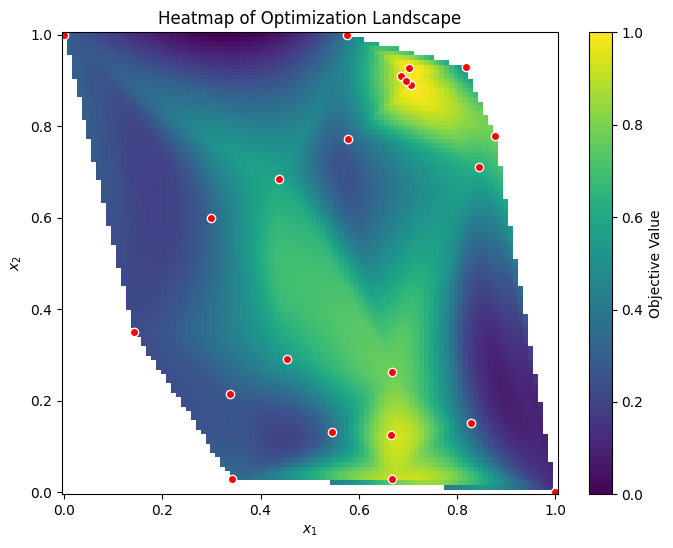

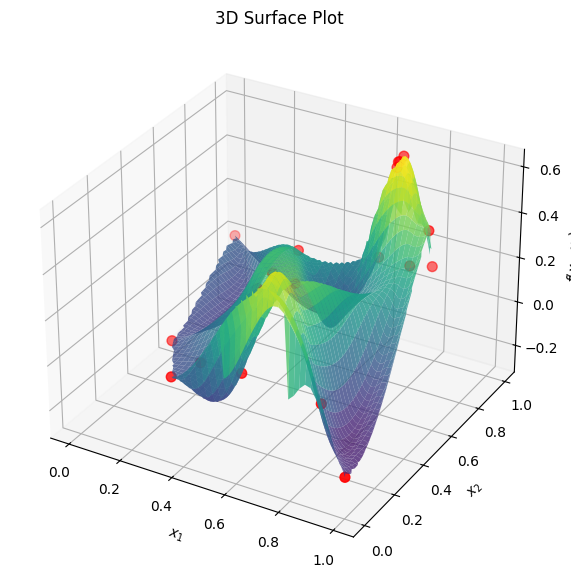

In [12]:
from scipy.interpolate import griddata



x_axis = X[:, 0]
y_axis = X[:, 1]

# 2. Create a dense grid for interpolation
xi = np.linspace(x_axis.min(), x_axis.max(), 100)
yi = np.linspace(y_axis.min(), y_axis.max(), 100)
XI, YI = np.meshgrid(xi, yi)

# 3. Interpolate the points onto the grid
ZI = griddata((x_axis, y_axis), y, (XI, YI), method='cubic')

# --- Plotting Heatmap ---
plt.figure(figsize=(8, 6))
plt.pcolormesh(XI, YI, ZI, shading='auto', cmap='viridis')
plt.scatter(x_axis, y_axis, c='red', edgecolors='white', label='Sample Points')
plt.colorbar(label='Objective Value')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Heatmap of Optimization Landscape')
plt.show()

# --- Plotting 3D Surface ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(XI, YI, ZI, cmap='viridis', alpha=0.8)
ax.scatter(x_axis, y_axis, y, color='red', s=50)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$f(x_1, x_2)$')
plt.title('3D Surface Plot')
plt.show()

In [13]:
noise_assumption = 1e-1

rbf_lengthscale = 0.05

#Define the kernel of the GP
kernel = C(1.0) * Matern(length_scale=0.1, length_scale_bounds=(0.01, 1.0), nu=1.5)

model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)

In [14]:
model.fit(X, y)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".","1**2 * Matern...e=0.1, nu=1.5)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",0.1
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",0
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`G

In [15]:
# 3. Create a search grid to find the next point
x_coords = np.linspace(0, 1, 100)
y_coords = np.linspace(0, 1, 100)
x_grid, y_grid = np.meshgrid(x_coords, y_coords)
X_test = np.vstack([x_grid.ravel(), y_grid.ravel()]).T

In [16]:
# 4. Predict Mean and Uncertainty (Standard Deviation)
mean, std = model.predict(X_test, return_std=True)

In [17]:
kappa = 10.0
ucb = mean + kappa * std
next_idx = np.argmax(ucb)
next_point = X_test[next_idx]

print(f"Suggested Next Iteration Point: {next_point}")

Suggested Next Iteration Point: [0. 0.]


In [39]:
from scipy.stats import norm


def expected_improvement(X, model, current_best, xi=0.001):
    """
    X: Points at which to evaluate EI
    model: Trained Gaussian Process
    current_best: Highest value found so far
    xi: Exploration parameter (higher = more exploration)
    """
    mu, sigma = model.predict(X, return_std=True)
    mu = mu.reshape(-1, 1)
    sigma = sigma.reshape(-1, 1)
    
    # Avoid division by zero
    mask = sigma > 0
    ei = np.zeros_like(mu)

    # Calculate Z with the exploration parameter xi
    # Standard EI: (mu - current_best) / sigma
    # Exploration EI: (mu - current_best - xi) / sigma
    improvement = mu[mask] - current_best - xi
    z = improvement / sigma[mask]
    
    ei[mask] = (improvement * norm.cdf(z) + 
                sigma[mask] * norm.pdf(z))
    
    return ei

In [40]:
# Get your current best output
current_best_y = np.max(y) 



In [41]:
# Calculate EI for all points in your grid
ei_values = expected_improvement(X_test, model, current_best_y)
next_idx = np.argmax(ei_values)
next_point = X_test[next_idx]
print(next_point)

[1. 1.]


In [42]:
# Third iteration
# kappa down from 5 to 0.5
# length scale down froma 0.1 to 0.05 
# objective is to investigate whether there is a connected ridge between the two peaks

In [43]:
import torch
# Custom Labels: Start with all zeros (Negative)
y_labels = np.zeros(len(X))

# Set indices 0,1,9,12
positive_indices = [0,1,9,12]
y_labels[positive_indices] = 1

# 1. Setup Data
X_tensor = torch.tensor(X, dtype=torch.float32, requires_grad=True)

# Labels: Indices 4, 9, 10, 11, 12 as 1, rest as 0
y_tensor = torch.tensor(y_labels, dtype=torch.float32).reshape(-1, 1)

In [44]:
# Deep layer

In [45]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Define a deeper architecture
model = nn.Sequential(
    nn.Linear(2, 10),      # Hidden layer: 2 inputs -> 10 neurons
    nn.ReLU(),             # Non-linear activation
    nn.Linear(10, 1),      # Output layer: 10 neurons -> 1 output
    nn.Sigmoid()
)

# 2. Setup the rest as before
optimizer = optim.Adam(model.parameters(), lr=0.01) # Adam is better for deeper nets
criterion = nn.BCELoss()

# 3. Training Loop
for _ in range(2000):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

In [46]:
# Clear gradients and do a fresh pass for saliency
X_tensor.grad.zero_()
output = model(X_tensor)
output.backward(torch.ones_like(output))

# Importance scores
deep_importance = X_tensor.grad.abs().sum(dim=1).detach().numpy()

print("Point | Deep Importance Score")
for i, score in enumerate(deep_importance):
    print(f"{i:2d}    | {score:.4f}")

Point | Deep Importance Score
 0    | 0.6419
 1    | 0.9695
 2    | 0.1206
 3    | 0.9335
 4    | 0.3577
 5    | 0.5448
 6    | 0.3559
 7    | 0.2371
 8    | 0.2403
 9    | 0.7470
10    | 0.9113
11    | 0.5546
12    | 0.6515
13    | 0.8870
14    | 0.4643
15    | 0.7516
16    | 0.6377
17    | 0.7214
18    | 0.0773
19    | 0.2209
20    | 1.0249


In [47]:
import torch

# 1. Prepare your sample input (must be a 2D tensor)
sample_input = torch.tensor([next_point], dtype=torch.float32)

# 2. Put the model in evaluation mode
model.eval()

# 3. Use 'no_grad' to save memory and compute power
with torch.no_grad():
    prediction_prob = model(sample_input)

# 4. View results
print(f"Probability of being Positive (Class 1): {prediction_prob.item():.4f}")

# Convert probability to a hard label
predicted_label = 1 if prediction_prob.item() >= 0.5 else 0
print(f"Predicted Class: {predicted_label}")

Probability of being Positive (Class 1): 0.5071
Predicted Class: 1


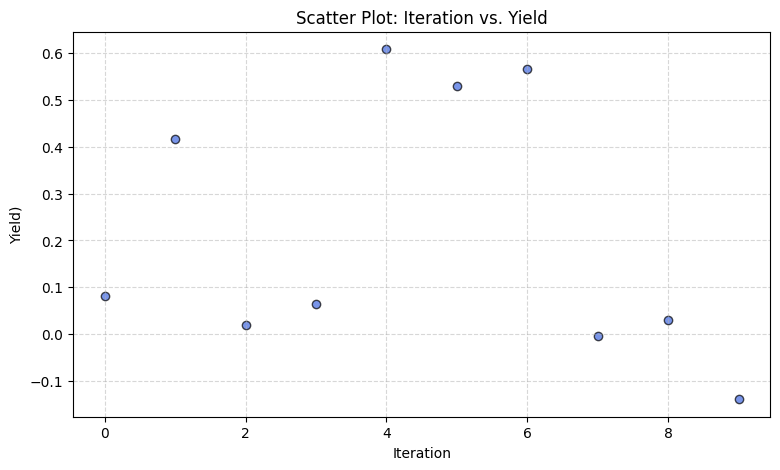

In [48]:
plt.figure(figsize=(9, 5))
plt.scatter(
    list(range(0,10)), y[-10:], color="royalblue", alpha=0.7, edgecolors="k"
)

# 3. Customization
plt.title("Scatter Plot: Iteration vs. Yield")
plt.xlabel("Iteration")
plt.ylabel("Yield)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()